In [4]:
def ema_smooth(data, alpha=0.3):
    """Экспоненциальное сглаживание."""
    if not data:
        return []
    smoothed = [data[0]]
    for x in data[1:]:
        smoothed.append(alpha * x + (1 - alpha) * smoothed[-1])
    return smoothed

In [3]:
import os
import json
import matplotlib.pyplot as plt
import math


def plot_losses(base_dir='.', target_exp_dirs=None, suffix=None):
    # Найти все подходящие директории, если явно не заданы
    if target_exp_dirs is None:
        exp_dirs = [d for d in os.listdir(base_dir)
                    if os.path.isdir(os.path.join(base_dir, d)) and
                    (d.startswith('constant_') or d.startswith('cosine_') or d.startswith('exp'))]
    else:
        exp_dirs = target_exp_dirs
    print("Found experiment dirs:", exp_dirs)

    all_experiments = []

    for exp_dir in exp_dirs:
        full_dir = os.path.join(base_dir, exp_dir)
        json_files = [f for f in os.listdir(full_dir) if f.startswith('traincfg_') and f.endswith('.json')]
        json_files.sort()
        if not json_files:
            continue

        with open(os.path.join(full_dir, json_files[-1]), 'r') as f:
            data = json.load(f)

        all_experiments.append({
            'alpha': data.get('alpha'),
            'gpu_id': data.get('gpu_id'),
            'metrics': data.get('metrics', {}),
            'exp_dir': exp_dir,
            'lambda_1': data.get('lambda_1', 1.0),
            'lambda_2': data.get('lambda_2', 1.0),
            'schedule_type': data.get('schedule_type', 'unknown')
        })

    # Собрать уникальные ключи из train_losses
    loss_keys = set()
    for exp in all_experiments:
        train_losses = exp['metrics'].get('train_losses', {})
        loss_keys.update(train_losses.keys())

    # Исключаем ненужные лоссы
    excluded = {'fashion_loss', 'distribution_loss'}
    loss_keys = sorted([k for k in loss_keys if k not in excluded])

    # Подготовка под двойной subplot (train + val)
    ncols = 2
    nrows = len(loss_keys)
    fig, axs = plt.subplots(nrows=nrows*2, ncols=1, figsize=(7 * ncols, 4 * nrows))

    if nrows == 1:
        axs = [axs]
    else:
        axs = axs

    for row_idx, loss_name in enumerate(loss_keys):
        ax_train = axs[2*row_idx]
        ax_val = axs[2*row_idx+1]

        for exp in sorted(all_experiments, key=lambda x: x['alpha'] if x['alpha'] is not None else 0):
            m = exp['metrics']
            alpha = exp['alpha']
            schedule = exp['schedule_type']
            label = f"α={alpha}, {schedule}" if alpha is not None else f"{exp['exp_dir']}, {schedule}"

            train_losses = m.get('train_losses', {}).get(loss_name)
            if not train_losses:
                continue

            # Трейн
            losses = train_losses
            print(losses[100], losses[-1])
            if suffix:
                losses = losses[-suffix:]
            ax_train.plot(losses, label=f"{label} train")

            # Валидация
            val_losses = m.get('val_losses', {}).get(loss_name)
            if val_losses:
                val_losses = val_losses # <- оставлено как ты просил
                # print(val_losses[100], val_losses[-1])
                if suffix:
                    val_losses = val_losses[-suffix:]
                
                val_iters = range(0, len(val_losses) * 10, 10)
                ax_val.plot(val_iters, val_losses, label=f"{label} val", linewidth=2)

        # Оформление
        ax_train.set_title(f"Train - {loss_name}")
        ax_train.set_xlabel("Iteration")
        ax_train.set_ylabel("Loss")
        ax_train.grid(True)
        ax_train.legend()

        ax_val.set_title(f"Val - {loss_name}")
        ax_val.set_xlabel("Iteration")
        ax_val.set_ylabel("Loss")
        ax_val.grid(True)
        ax_val.legend()

    plt.suptitle("Train / Val Losses per Metric", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


Found experiment dirs: ['exp_alpha1.00_gpu5', 'constant_alpha0.20_gpu2', 'exp_increase_alpha1.00_gpu7', 'cosine_alpha0.50_gpu4', 'constant_alpha1.00_gpu6', 'constant_alpha1.00_gpu7', 'constant_alpha0.50_gpu4', 'cosine_alpha1.00_gpu6', 'exp_increase_alpha0.50_gpu7', 'constant_alpha100.00_gpu7', 'exp_increase_alpha0.20_gpu7', 'cosine_rise_decay_alpha1.00_gpu6', 'cosine_increase_alpha1.00_gpu6', 'cosine_rise_decay_alpha0.50_gpu4', 'cosine_increase_alpha0.20_gpu6', 'constant_alpha0.40_gpu4', 'constant_alpha0.50_gpu6', 'constant_alpha0.00_gpu0', 'constant_alpha0.60_gpu6', 'constant_alpha50.00_gpu7', 'constant_alpha0.10_gpu7', 'cosine_alpha1.00_gpu4', 'cosine_hold_alpha1.00_gpu6', 'exp_increase_alpha0.70_gpu7', 'constant_alpha50.00_gpu6', 'constant_alpha0.80_gpu7', 'cosine_alpha0.20_gpu4', 'constant_alpha100.00_gpu6', 'cosine_rise_decay_alpha0.20_gpu4', 'exp_alpha1.00_gpu7', 'cosine_alpha0.70_gpu4', 'cosine_rise_decay_alpha0.70_gpu4', 'cosine_hold_alpha0.20_gpu6', 'exp_alpha0.20_gpu5']
4.156

/tmp/ipykernel_3631028/2100396740.py:105: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


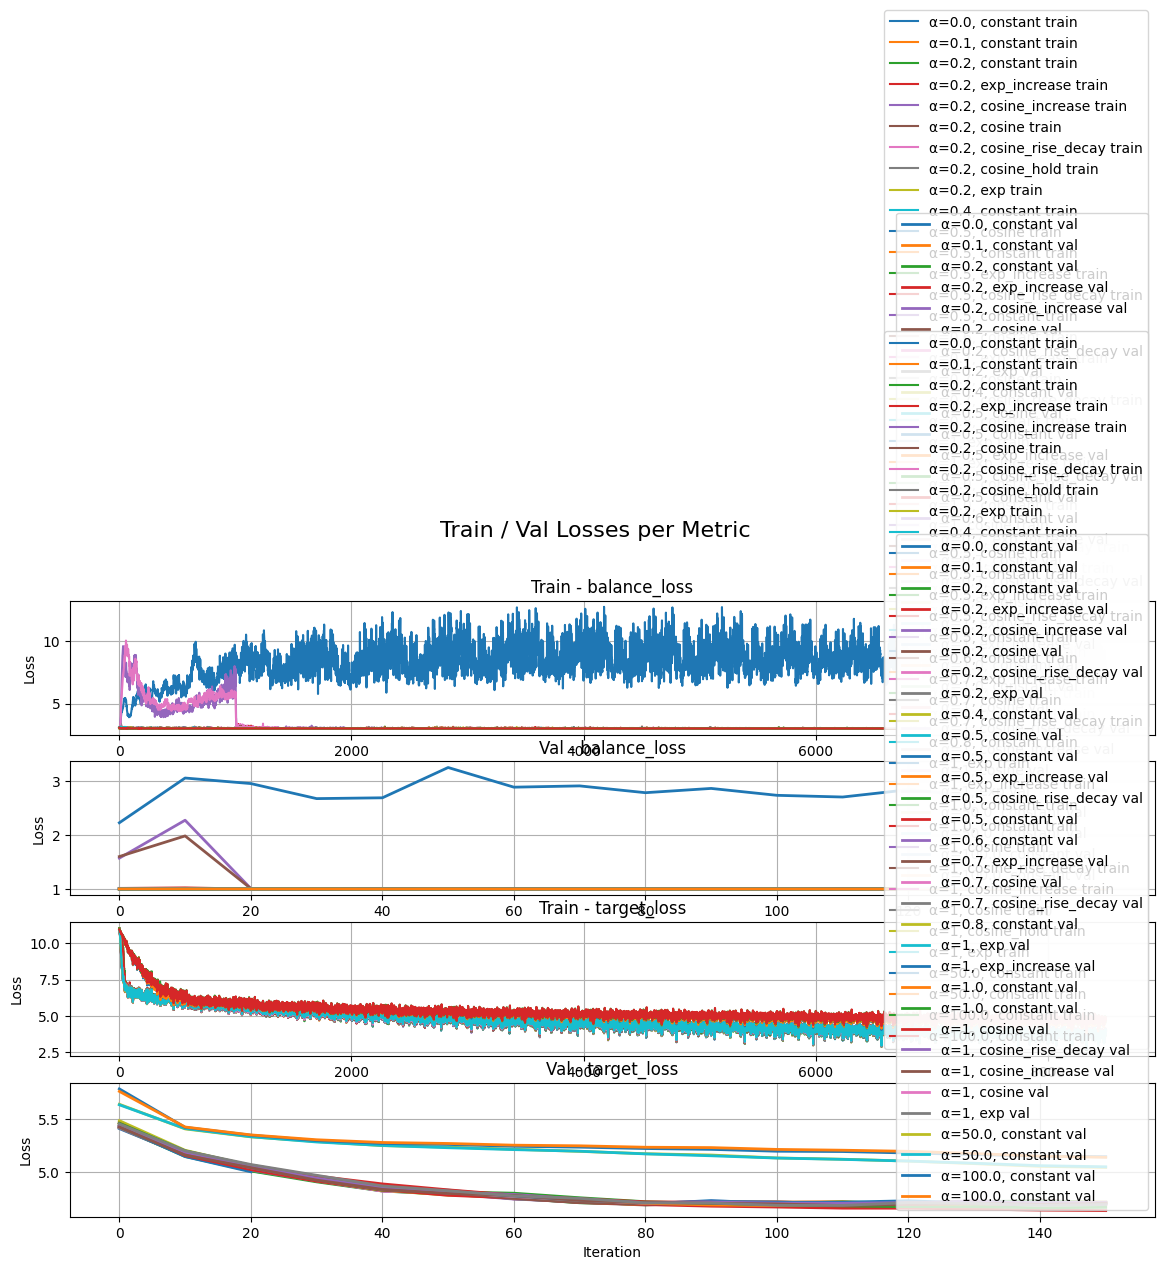

In [4]:
plot_losses(suffix=None)

In [26]:
def get_alpha_scheduler(
    schedule_type: str,
    base_alpha: float,
    total_steps: int,
    warmup_steps: int = 0,
    period: Optional[int] = None,
    hold_steps: Optional[int] = None,
    warmup_strategy: str = "linear",
    rise_fraction: float = 0.5,
):
    """
    Расширенный планировщик для alpha с новыми типами расписаний:
    
    Параметры:
        schedule_type: Один из:
            - 'constant' (постоянный)
            - 'linear' (линейный спад)
            - 'cosine' (косинусный спад)
            - 'exp' (экспоненциальный спад)
            - 'cosine_rise' (рост по косинусу + спад)
            - 'exp_rise' (рост экспоненциально + спад)
            - 'sawtooth' (пилообразный периодический)
            - 'cosine_hold' (плато + косинусный спад)
        base_alpha: Максимальное значение alpha
        total_steps: Общее число шагов
        warmup_steps: Число шагов для разогрева
        period: Период для пилообразного расписания
        hold_steps: Число шагов удержания максимума для cosine_hold
    """
    # Нормализуем типы расписаний (синонимы)
    aliases = {
        "exponential": "exp",
        "exp_decay": "exp",
        "linear_decay": "linear",
        "cosine_decay": "cosine",
        "cosine_increase": "cosine_increase",
        "exp_increase": "exp_increase",
        "cosine_rise_decay": "cosine_rise_decay",
        "saw": "sawtooth",
    }
    schedule_type = aliases.get(schedule_type, schedule_type)

    def scheduler(step: int):
        # Специальная логика для cosine_increase:
        # 1) первые warmup_steps: alpha = 0
        # 2) следующие warmup_steps: линейный рост 0 -> base_alpha
        # 3) далее: косинусное уменьшение base_alpha -> 0 на остатке шагов
        if schedule_type == 'cosine_increase':
            if step < warmup_steps:
                return 0.0
            # фаза роста
            adjusted_step = step - warmup_steps
            rise_steps = max(1, warmup_steps)
            if adjusted_step < rise_steps:
                return base_alpha * (float(adjusted_step) / float(rise_steps))
            # косинусный спад на остатке
            decay_total = max(1, total_steps - warmup_steps - rise_steps)
            decay_step = min(max(0, adjusted_step - rise_steps), decay_total)
            decay_progress = float(decay_step) / float(decay_total)
            return base_alpha * 0.5 * (1 + math.cos(math.pi * decay_progress))

        # Общая фаза разогрева для остальных типов
        if step < warmup_steps:
            if warmup_strategy == "zero":
                return 0.0
            # по умолчанию линейный разогрев
            return base_alpha * float(step) / float(max(1, warmup_steps))
        
        # Основные фазы
        adjusted_step = step - warmup_steps
        adjusted_total = total_steps - warmup_steps
        progress = float(adjusted_step) / float(max(1, adjusted_total))
        
        if schedule_type == 'constant':
            return base_alpha
            
        elif schedule_type == 'linear':
            return base_alpha * (1 - progress)
            
        elif schedule_type == 'cosine':
            return base_alpha * 0.5 * (1 + math.cos(math.pi * progress))
            
        elif schedule_type == 'exp':
            return base_alpha * (0.1 ** progress)
        elif schedule_type == 'exp_increase':
            # Экспоненциальное возрастание 0 -> base_alpha
            return base_alpha * (1.0 - (0.1 ** progress))

        elif schedule_type == 'cosine_rise_decay':
            # Нулевая или линейная пауза уже пройдена в warmup; теперь сначала рост по косинусу,
            # затем спад по косинусу с границей в доле rise_fraction
            rf = max(1e-6, min(1.0 - 1e-6, rise_fraction))
            if progress < rf:
                local = progress / rf
                return base_alpha * 0.5 * (1 - math.cos(math.pi * local))
            else:
                local = (progress - rf) / (1.0 - rf)
                return base_alpha * 0.5 * (1 + math.cos(math.pi * local))
                
        elif schedule_type == 'sawtooth':
            if period is None:
                period = adjusted_total // 4
            cycle_pos = adjusted_step % period
            return base_alpha * (1 - cycle_pos / period)
            
        elif schedule_type == 'cosine_hold':
            if hold_steps is None:
                hold_steps = adjusted_total // 3
            if adjusted_step < hold_steps:
                return base_alpha
            else:
                hold_progress = (adjusted_step - hold_steps) / (adjusted_total - hold_steps)
                return base_alpha * 0.5 * (1 + math.cos(math.pi * hold_progress))
                
        else:
            raise ValueError(f"Unknown schedule type: {schedule_type}")
    
    return scheduler

UnboundLocalError: cannot access local variable 'hold_steps' where it is not associated with a value

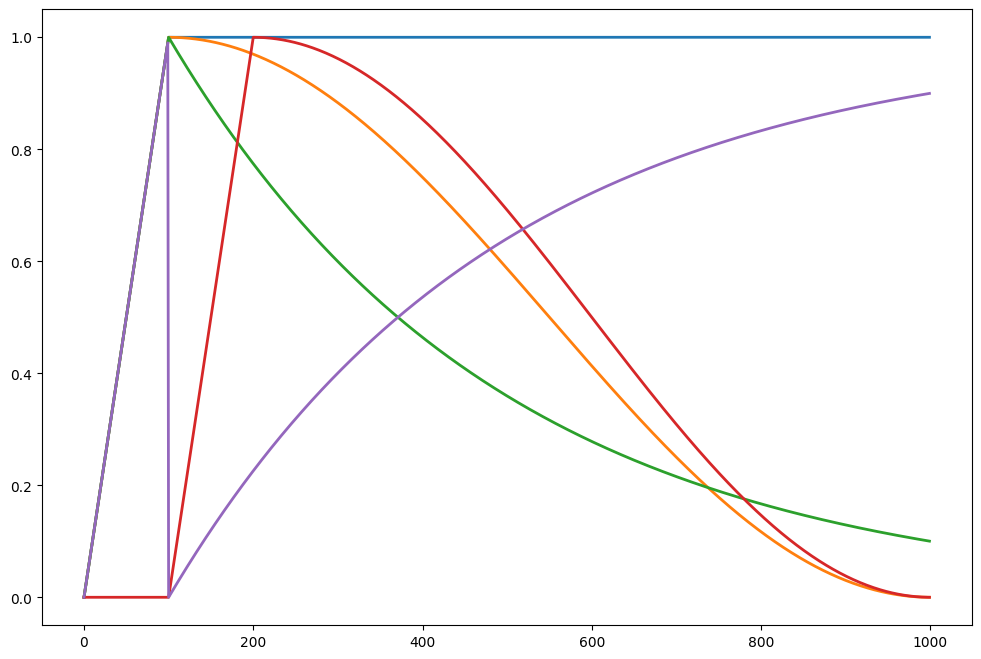

In [28]:
import math
import matplotlib.pyplot as plt
from typing import Optional

def visualize_schedules():
    # Параметры для визуализации

    
    # Все типы расписаний
    schedule_types = [
        'constant',
        # 'linear',
        'cosine',
        'exp',
        'cosine_increase',
        'exp_increase',
        # 'cosine_rise_decay',
        # 'sawtooth',
        'cosine_hold'
    ]
    
    # Создаем график
    plt.figure(figsize=(12, 8))
    
    # Генерируем и рисуем каждое расписание
    for schedule_type in schedule_types:
        scheduler = get_alpha_scheduler(
            schedule_type=schedule_type,
            base_alpha=base_alpha,
            total_steps=total_steps,
            warmup_steps=warmup_steps,
            period=period,
            hold_steps=hold_steps,
            warmup_strategy="linear",
            rise_fraction=rise_fraction
        )
        
        steps = list(range(total_steps))
        alphas = [scheduler(step) for step in steps]
        
        plt.plot(steps, alphas, label=schedule_type, linewidth=2)
    
    # Настраиваем график
    plt.title('Alpha Schedulers Comparison', fontsize=14)
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Alpha value', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.axvline(x=warmup_steps, color='gray', linestyle='--', alpha=0.5)
    plt.text(warmup_steps + 10, 0.9, 'end of warmup', color='gray')
    
    plt.tight_layout()
    plt.show()

# Вызываем функцию визуализации
visualize_schedules()

In [11]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

def visualize_experiments(dirs: list[str], suffix=None, distr=False):
    """
    Рисует:
    - Train/val лоссы на разных сабплотах
    - Историю шедулинга альфы (schedule_hist)
    - Heatmap gate_distr
    """
    loss_names = ["target_loss", "balance_loss"]
    titles = ["Target Loss", "Balance Loss"]

    # фигура 1: 4 сабплота — train/val отдельно
    fig1, axes1 = plt.subplots(5, 1, figsize=(14, 30))
    axes1 = axes1.flatten()

    # палитра цветов
    # color_cycle = plt.cm.tab10(np.linspace(0, 1, len(dirs)))

    # фигура 2: heatmap и шедулер
    fig2, (ax_hm, ax_sched) = plt.subplots(2, 1, figsize=(7, 10))

    for exp_idx, exp_dir in enumerate(dirs):
        print(exp_dir)
        # if 'alpha0.00' in exp_dir: continue
        json_files = [f for f in os.listdir(exp_dir) if f.endswith(".json")]
        if not json_files:
            print(f"⚠️ Нет JSON в {exp_dir}")
            continue
        json_files.sort()
        json_path = os.path.join(exp_dir, json_files[-1])

        with open(json_path, "r") as f:
            cfg = json.load(f)

        metrics = cfg.get("metrics", {})
        label = f"{exp_dir}_{cfg.get('schedule_type', '?')} α={cfg.get('alpha', '?')}"
        # color = color_cycle[exp_idx]

        train_losses = metrics.get("train_losses", {})
        val_losses = metrics.get("val_losses", {})

        # --- Лоссы ---
        for idx, loss_name in enumerate(loss_names):
            train_data = train_losses.get(loss_name, [])
            val_data = val_losses.get(loss_name, [])

            if 'balance' in loss_name:
                train_data = [t/3 for t in train_data]
            if suffix:
                train_data = train_data[-suffix:]
                val_data = val_data[-suffix:]

            # --- сглаживание train loss ---
            train_data_smooth = ema_smooth(train_data, alpha=0.05)

            if train_data_smooth:
                axes1[idx * 2].plot(range(len(train_data_smooth)), train_data_smooth,
                                    label=f"{label} train", alpha=0.8)
                axes1[idx * 2].set_title(f"{titles[idx]} — Train")
                axes1[idx * 2].set_xlabel("Train iterations")
                axes1[idx * 2].set_ylabel("Loss")

            if val_data:
                axes1[idx * 2 + 1].plot(range(len(val_data)), val_data,
                                        label=f"{label} val", linestyle="--", alpha=0.8)
                axes1[idx * 2 + 1].set_title(f"{titles[idx]} — Val")
                axes1[idx * 2 + 1].set_xlabel("Validation steps")
                axes1[idx * 2 + 1].set_ylabel("Loss")

        # # --- Heatmap gate_distr ---
        if distr:
            gate_distr = metrics.get("gate_distr", [])
            if suffix:
                gate_distr = gate_distr[-suffix:]
            if gate_distr:
                iters = [g["iter"] for g in gate_distr]
                distrs = np.array([g["distr"] for g in gate_distr]).T
                im = ax_hm.imshow(
                    distrs, aspect="auto", origin="lower",
                    extent=[min(iters), max(iters), 0, distrs.shape[0]],
                    cmap="viridis"
                )
                ax_hm.set_title(f"Gate Distribution — {label}")
                ax_hm.set_xlabel("Iteration")
                ax_hm.set_ylabel("Expert ID")
                fig2.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04)

        # --- Alpha schedule ---афывааввваыаваыфва
        alpha_schedule = metrics.get("schedule_hist", [])
        if suffix:
            alpha_schedule = alpha_schedule[-suffix:]
        if alpha_schedule:
            ax_sched.plot(range(len(alpha_schedule)), alpha_schedule,
                          label=f"{label} α schedule", alpha=0.2)
            ax_sched.set_title("Alpha Schedule")
            ax_sched.set_xlabel("Step")
            ax_sched.set_ylabel("Alpha")

    # Легенды
    # Легенды с сортировкой
    for ax in axes1:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0])
            labels, handles = zip(*sorted_pairs)
            ax.legend(handles, labels)

    # Легенда для графика альфы
    handles, labels = ax_sched.get_legend_handles_labels()
    if handles:
        sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0])
        labels, handles = zip(*sorted_pairs)
        ax_sched.legend(handles, labels)


    ax_sched.legend()

    plt.tight_layout()
    plt.show()


metrics_gumbel/exp_alpha1.00_gpu0
metrics/exp_alpha1.00_gpu4


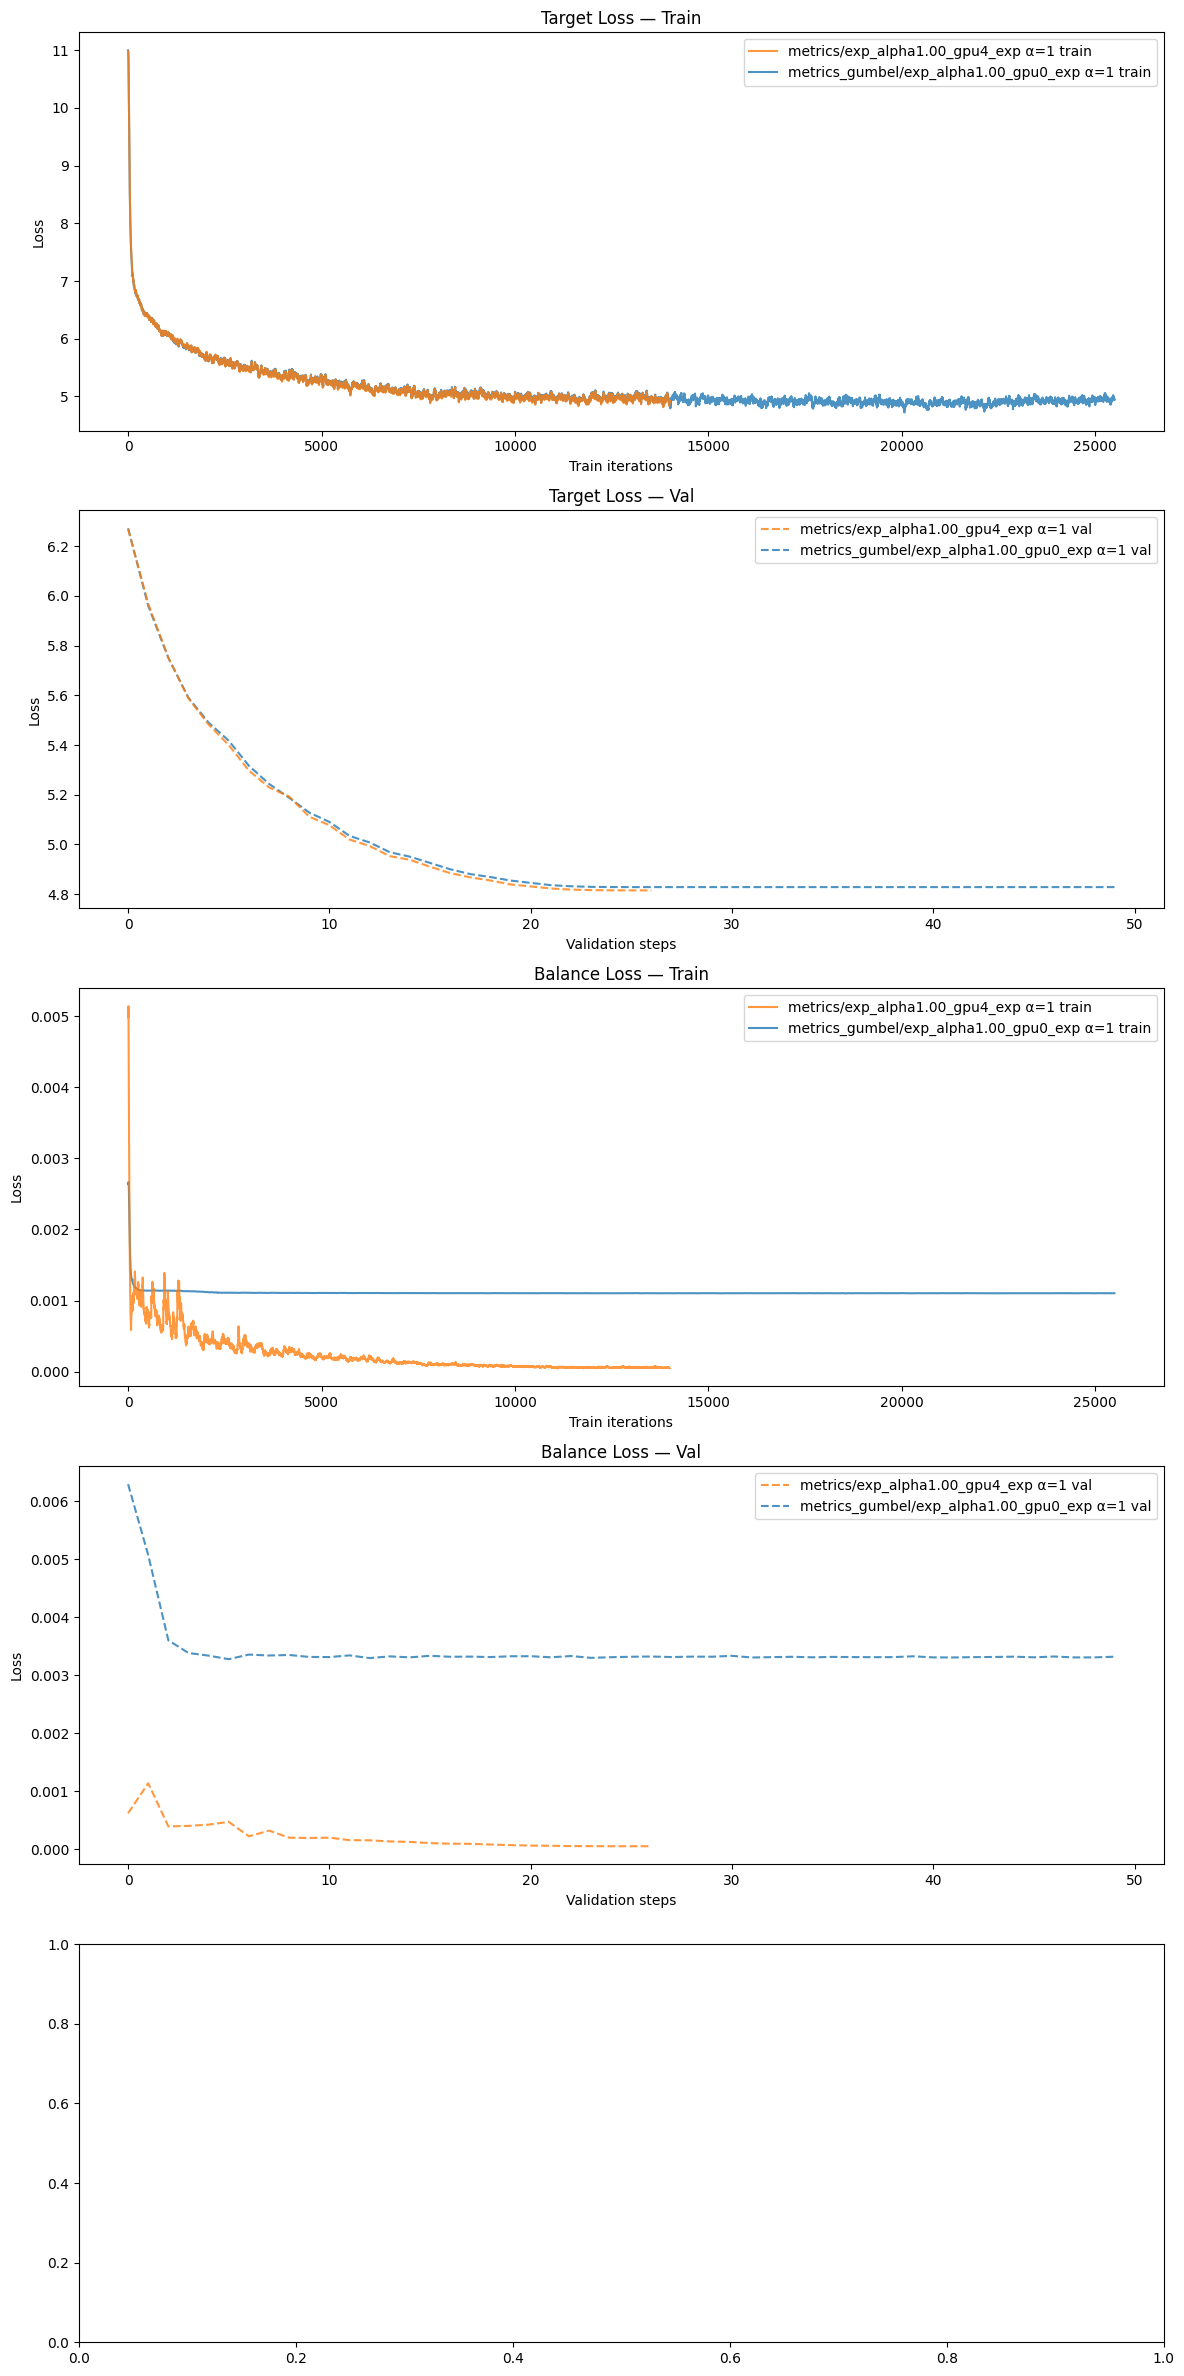

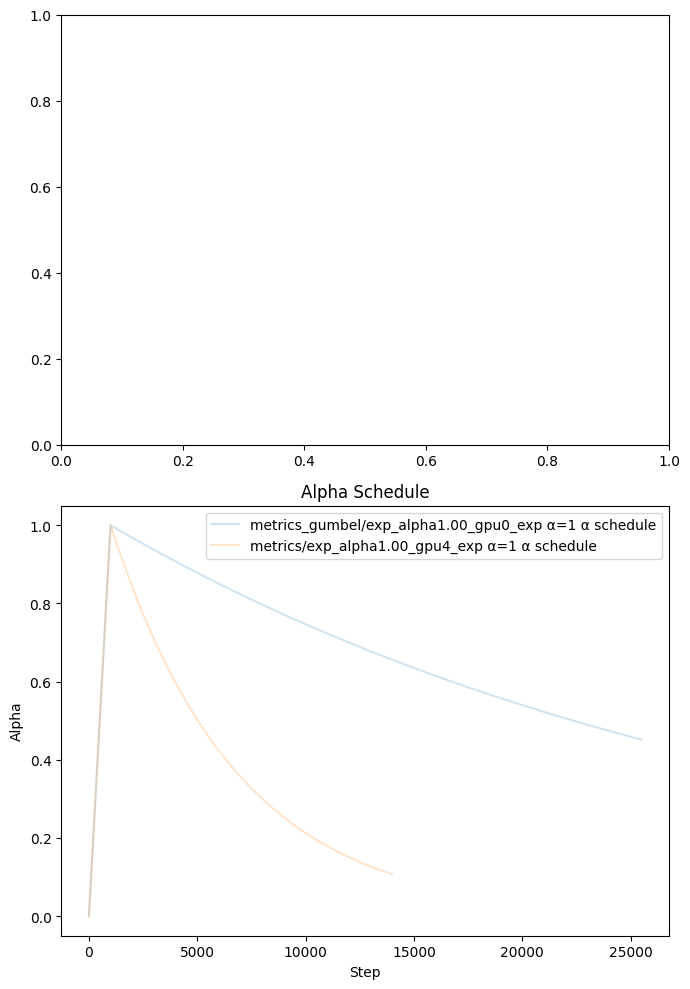

In [15]:
exp_dirs = [f'metrics_gumbel/exp_alpha1.00_gpu0', 'metrics/exp_alpha1.00_gpu4']
import os
visualize_experiments(exp_dirs, suffix=None)

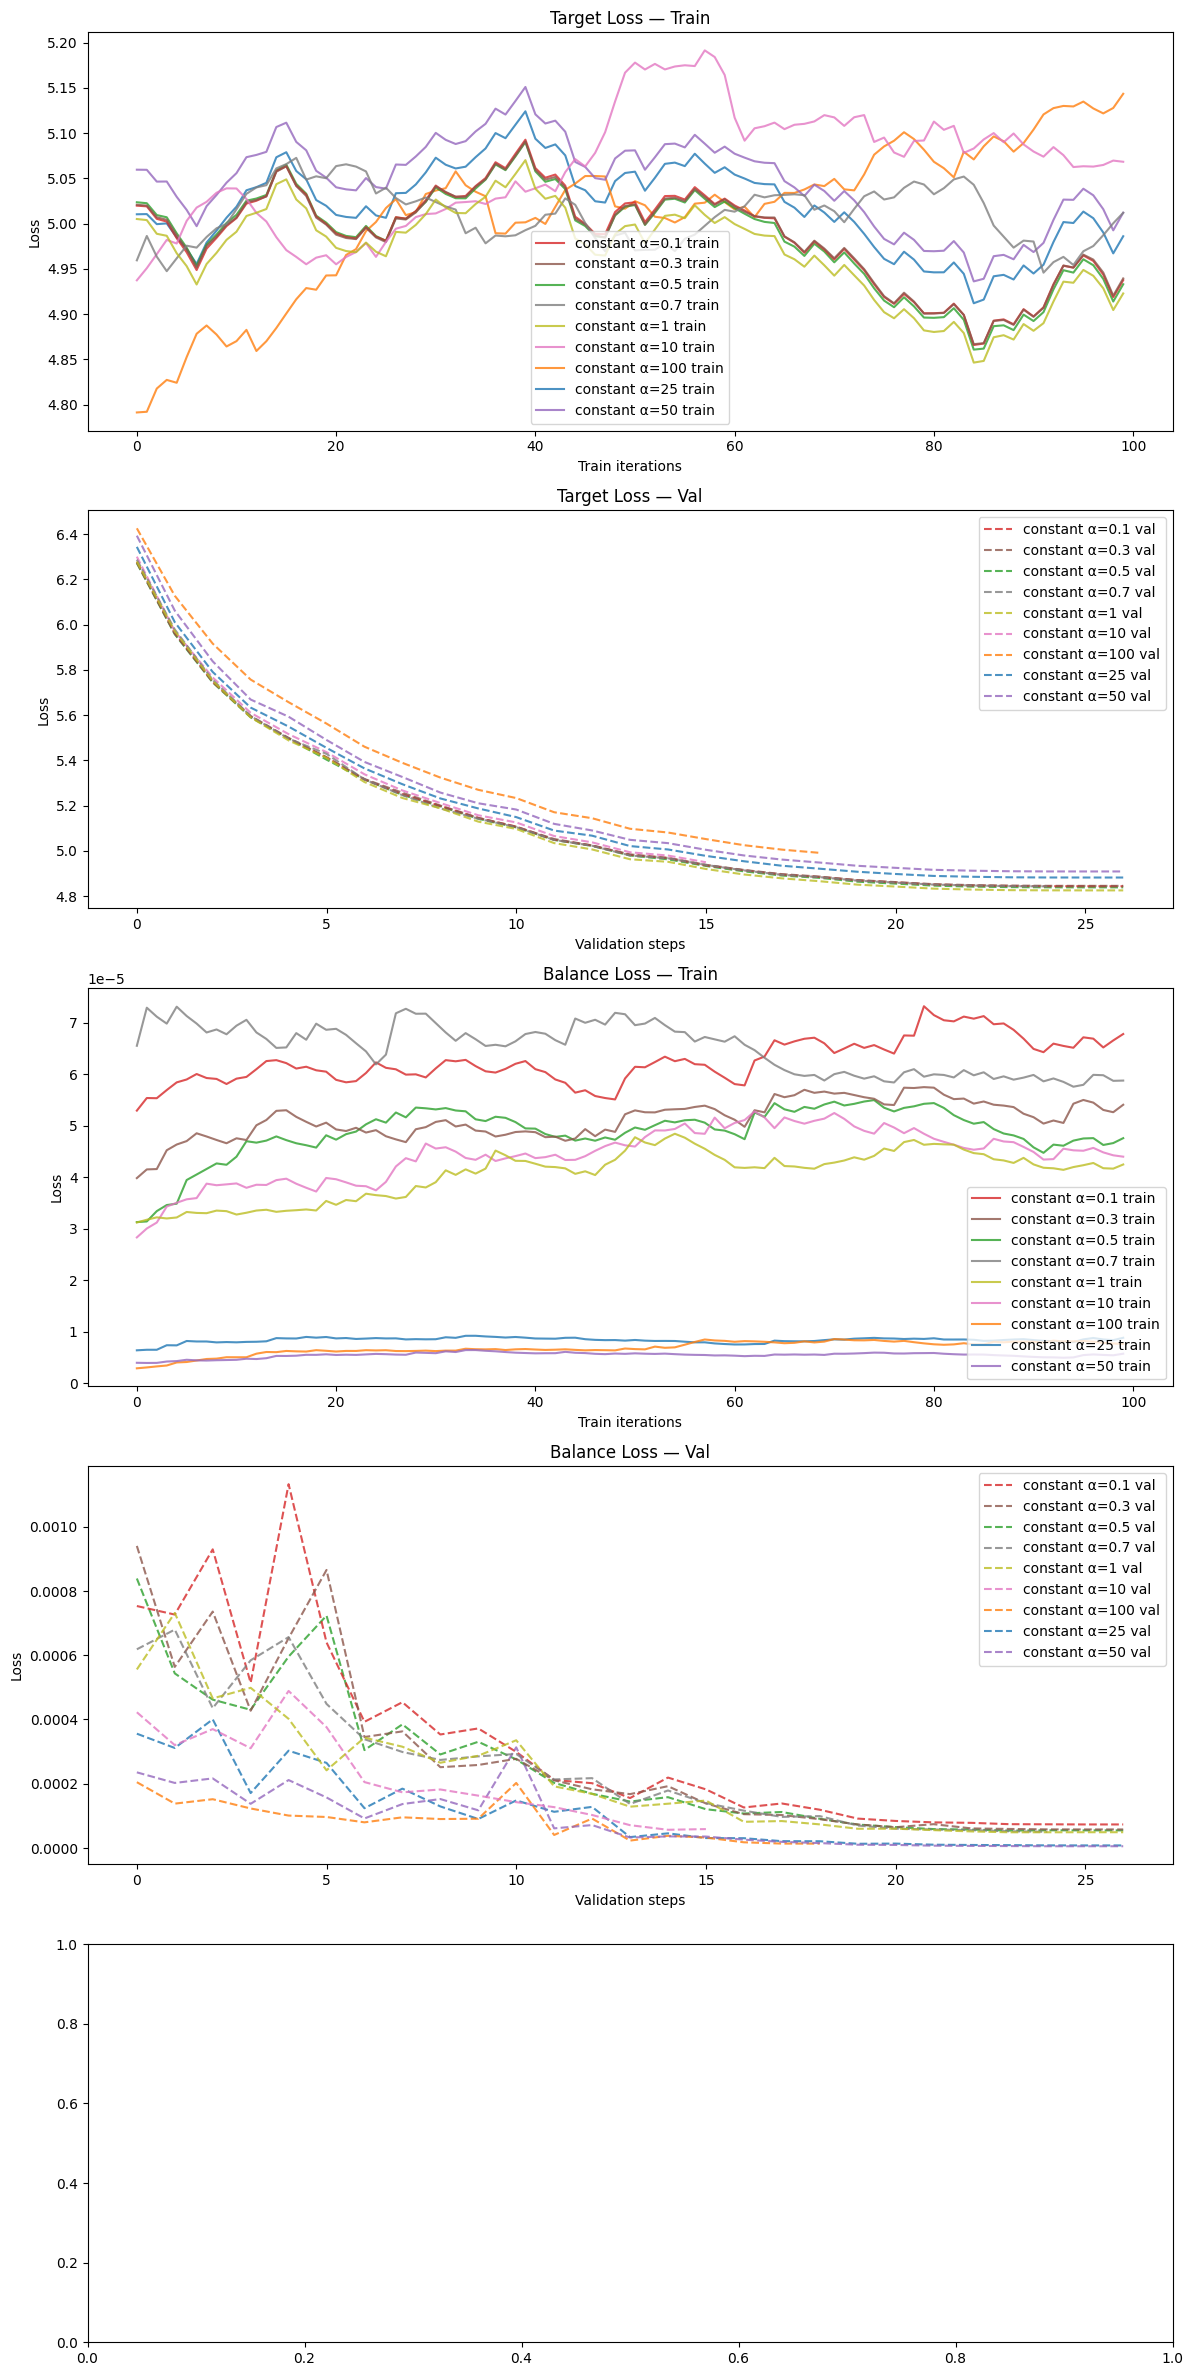

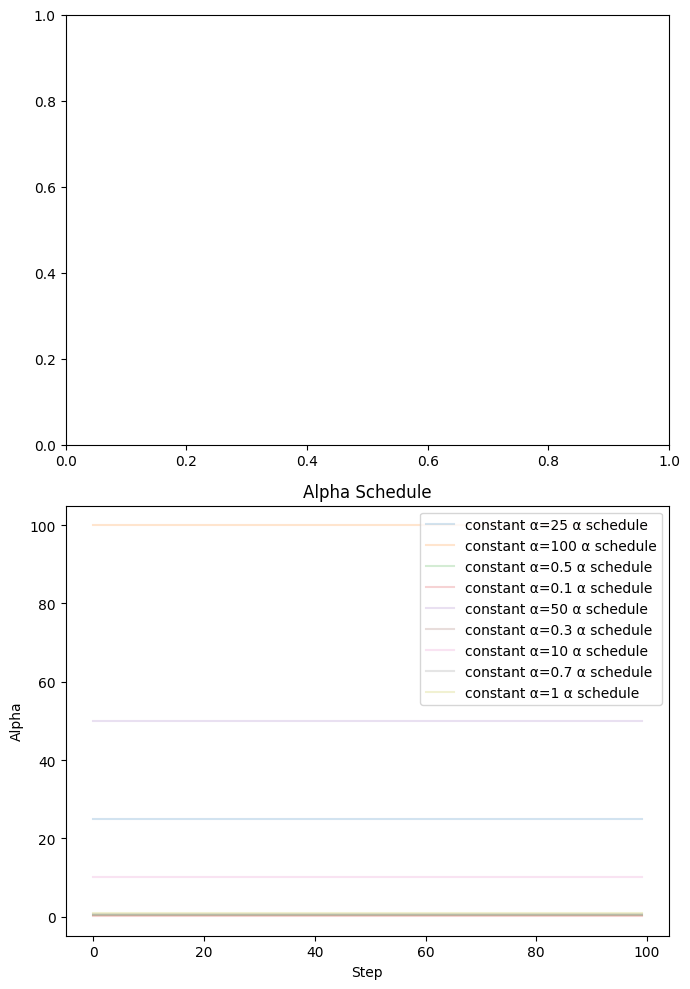

In [27]:
exp_dirs = [f'metrics/{d}' for d in os.listdir('metrics') if d[:-1].endswith('gpu') if 'const' in d]
import os
visualize_experiments(exp_dirs, suffix=100)

exp_alpha1.00_gpu4
cosine_alpha1.00_gpu2
linear_alpha1.00_gpu1
cosine_alpha1.00_gpu4
linear_alpha1.00_gpu4


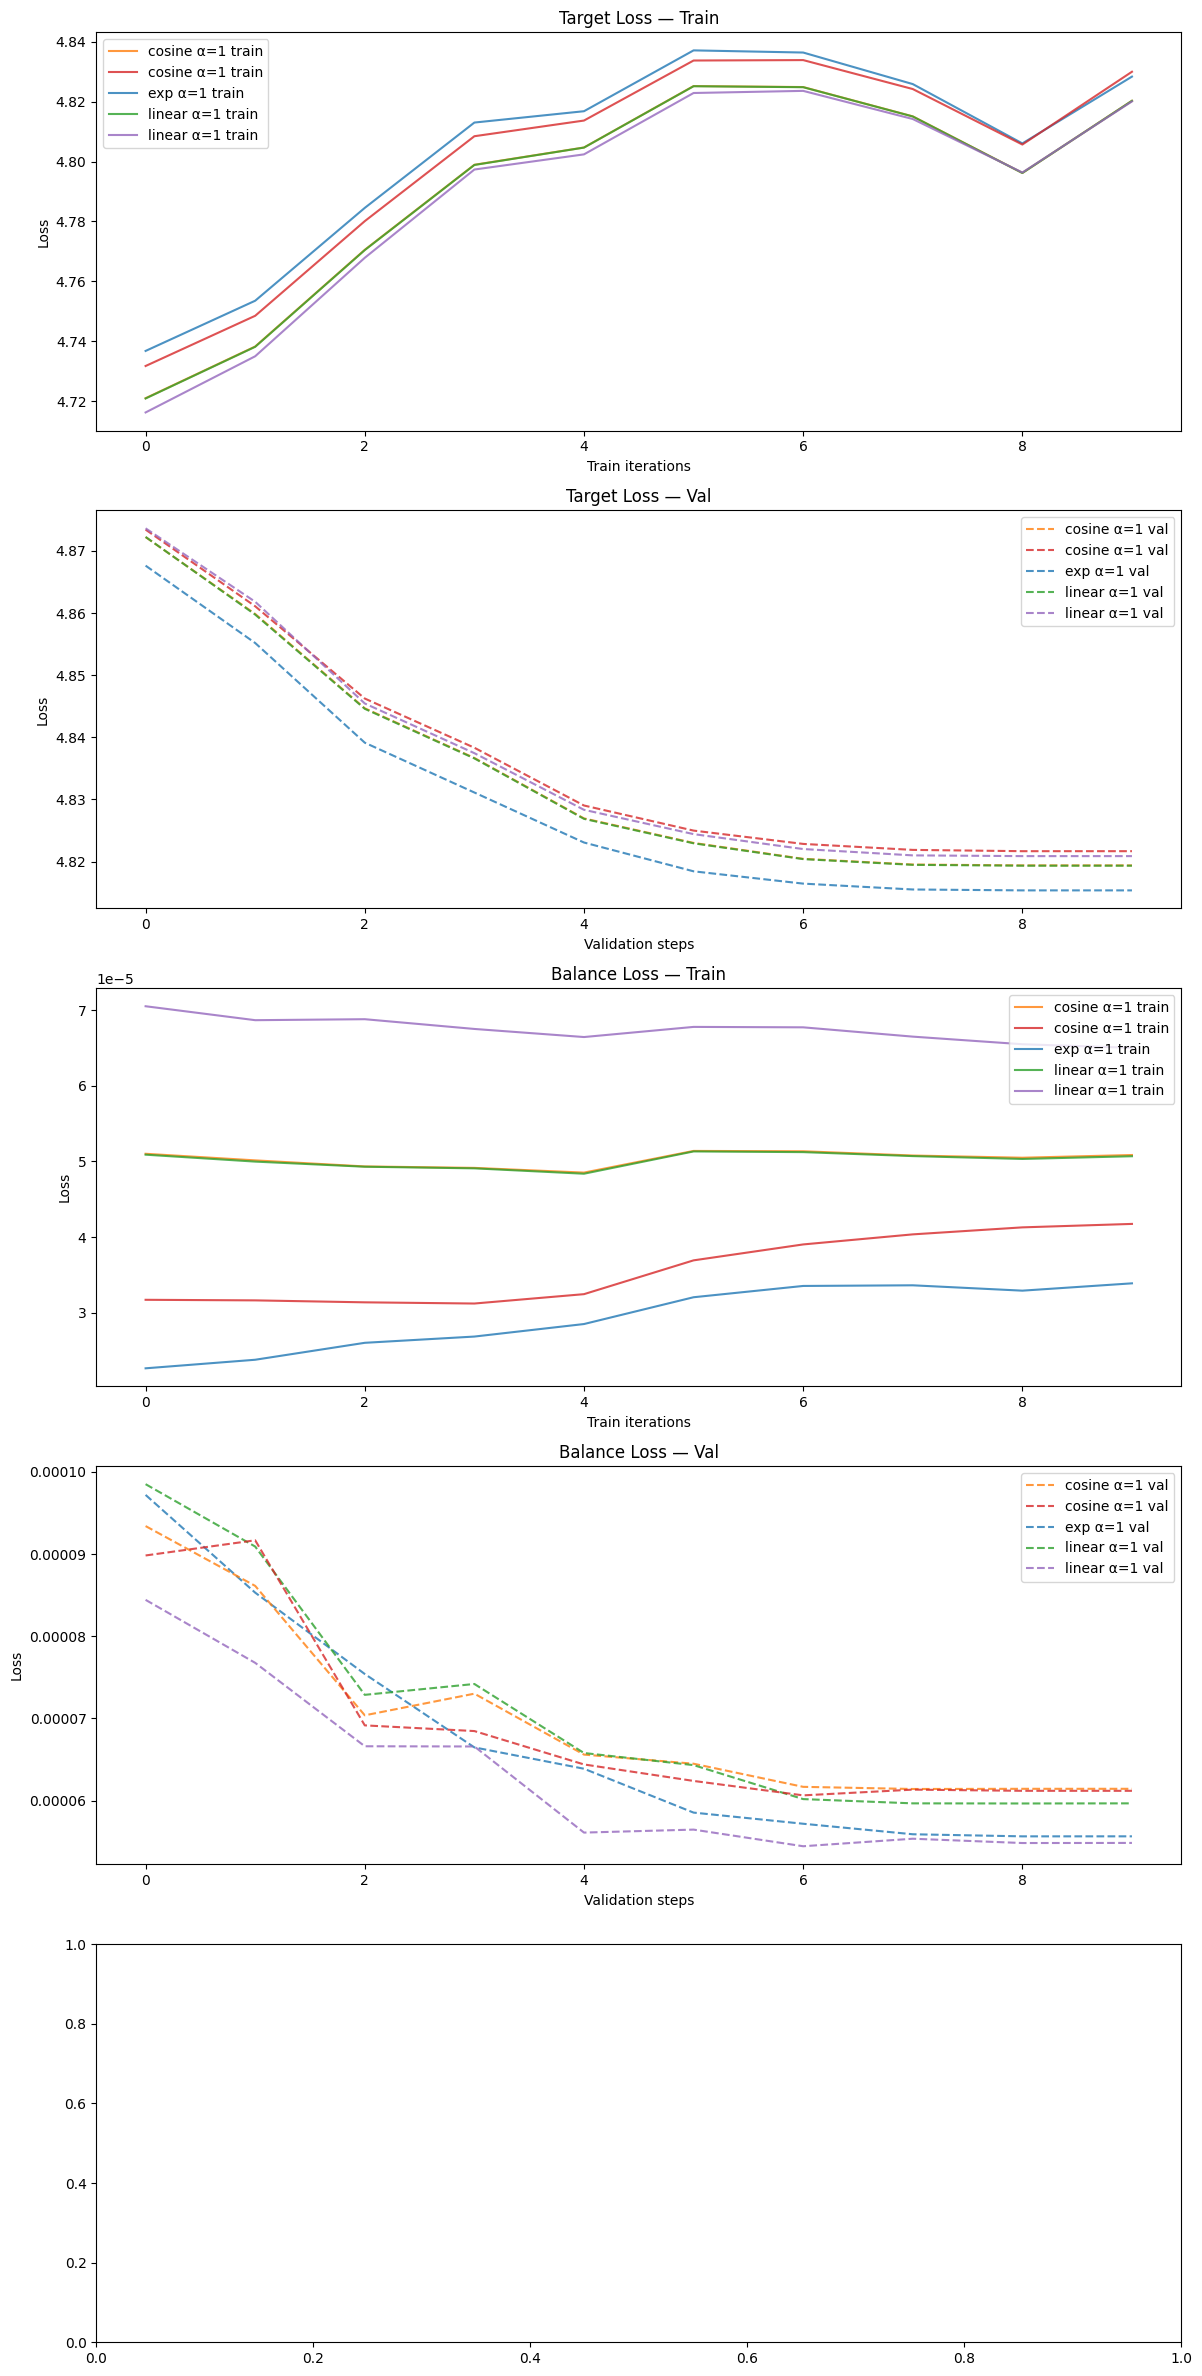

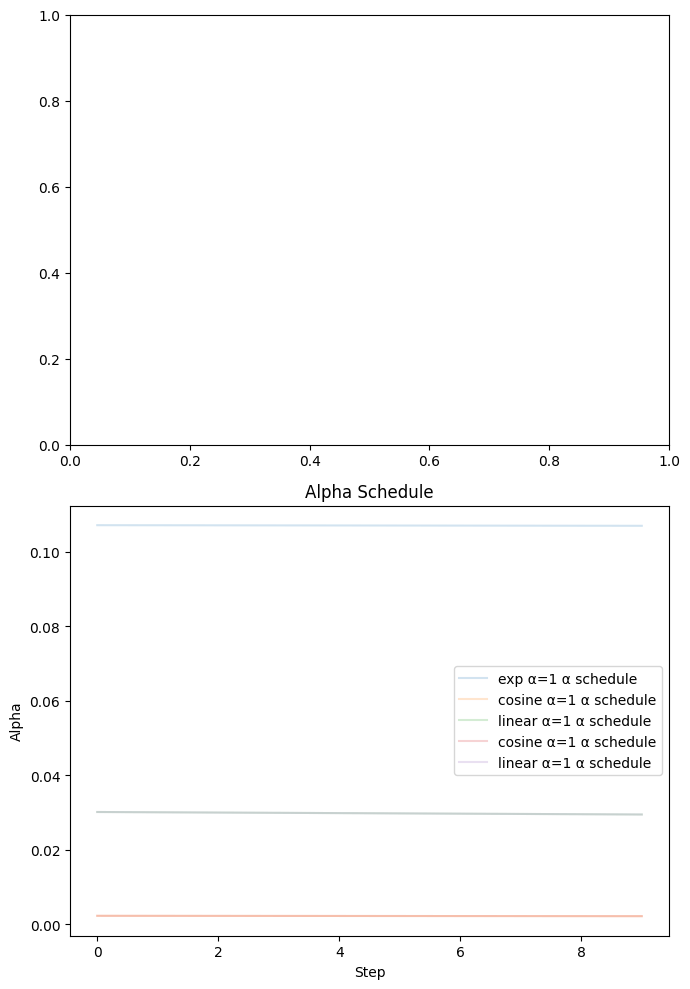

In [39]:
# exp_dirs = [
#     "metrics/constant_alpha0.40_gpu4",
#     # "linear_alpha0.50_gpu0",
#     # "cosine_alpha0.70_gpu0"
# ]
nigger = ['const', 'rise', 'saw', 'incre']
# nigger = []
exp_dirs = []
for d in os.listdir('metrics'):
    # if d[:-1].endswith('gpu'):
    #     exp_dirs.append(f'metrics/{d}')
    # print(d, nigger[0], nigger[0] in d)
    if not any(item in d for item in nigger):
        print(d)
        exp_dirs.append(f'metrics/{d}')
import os
visualize_experiments(exp_dirs, suffix=10)


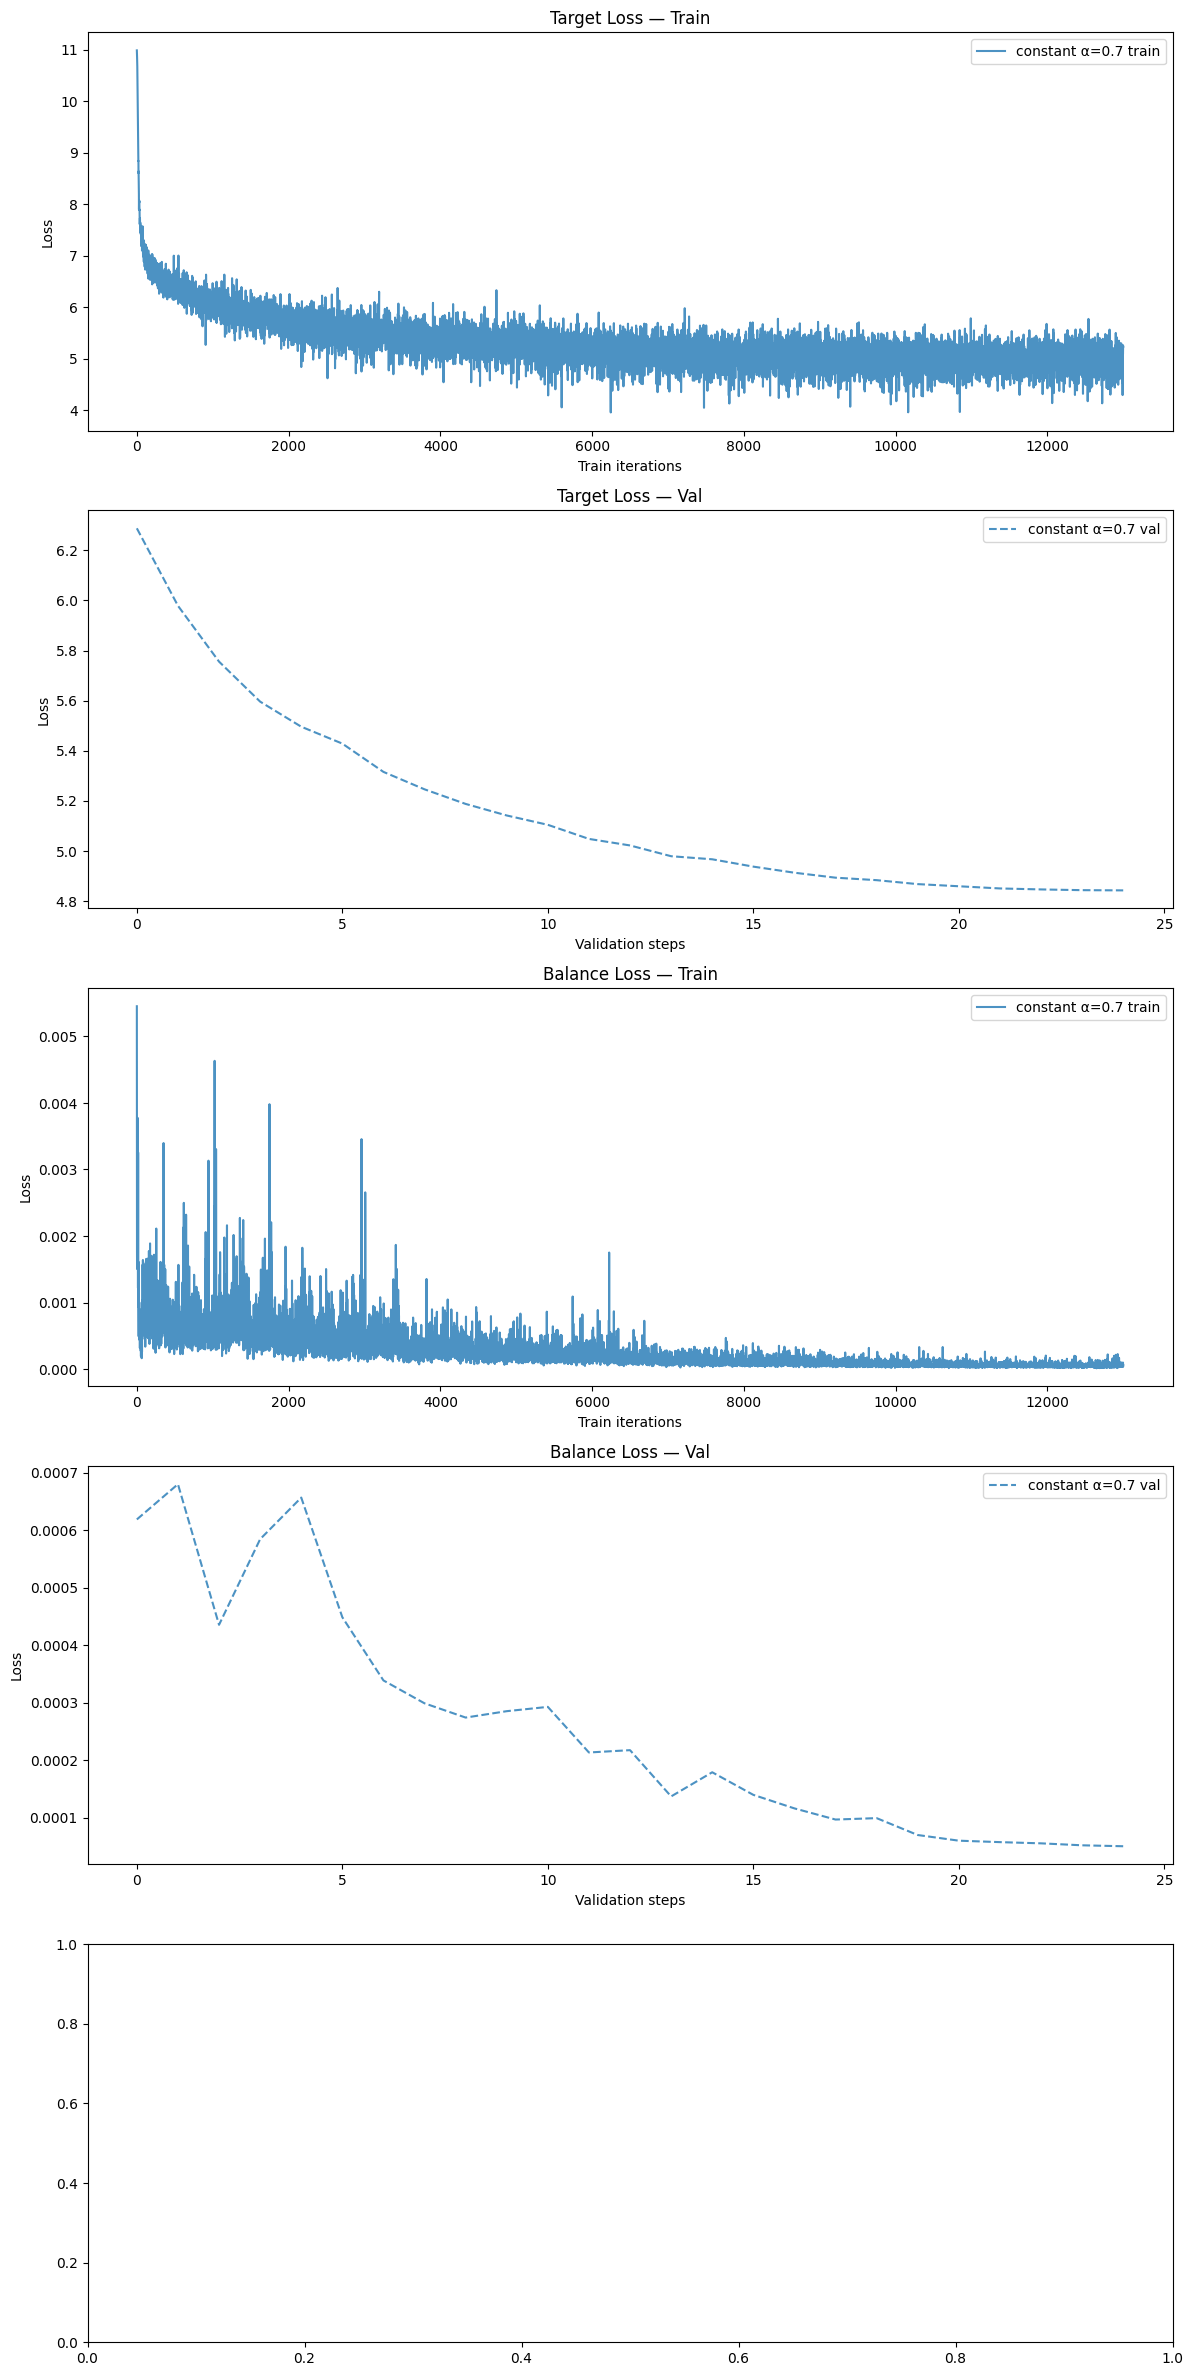

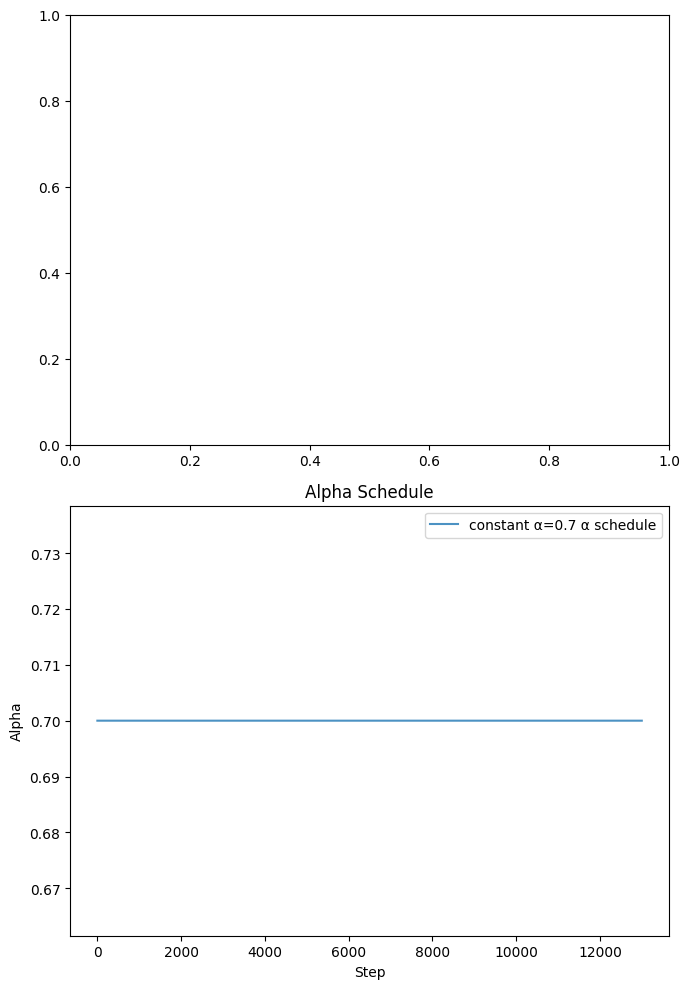

In [37]:
visualize_experiments(['metrics/constant_alpha0.70_gpu1'], suffix=None, distr=True)

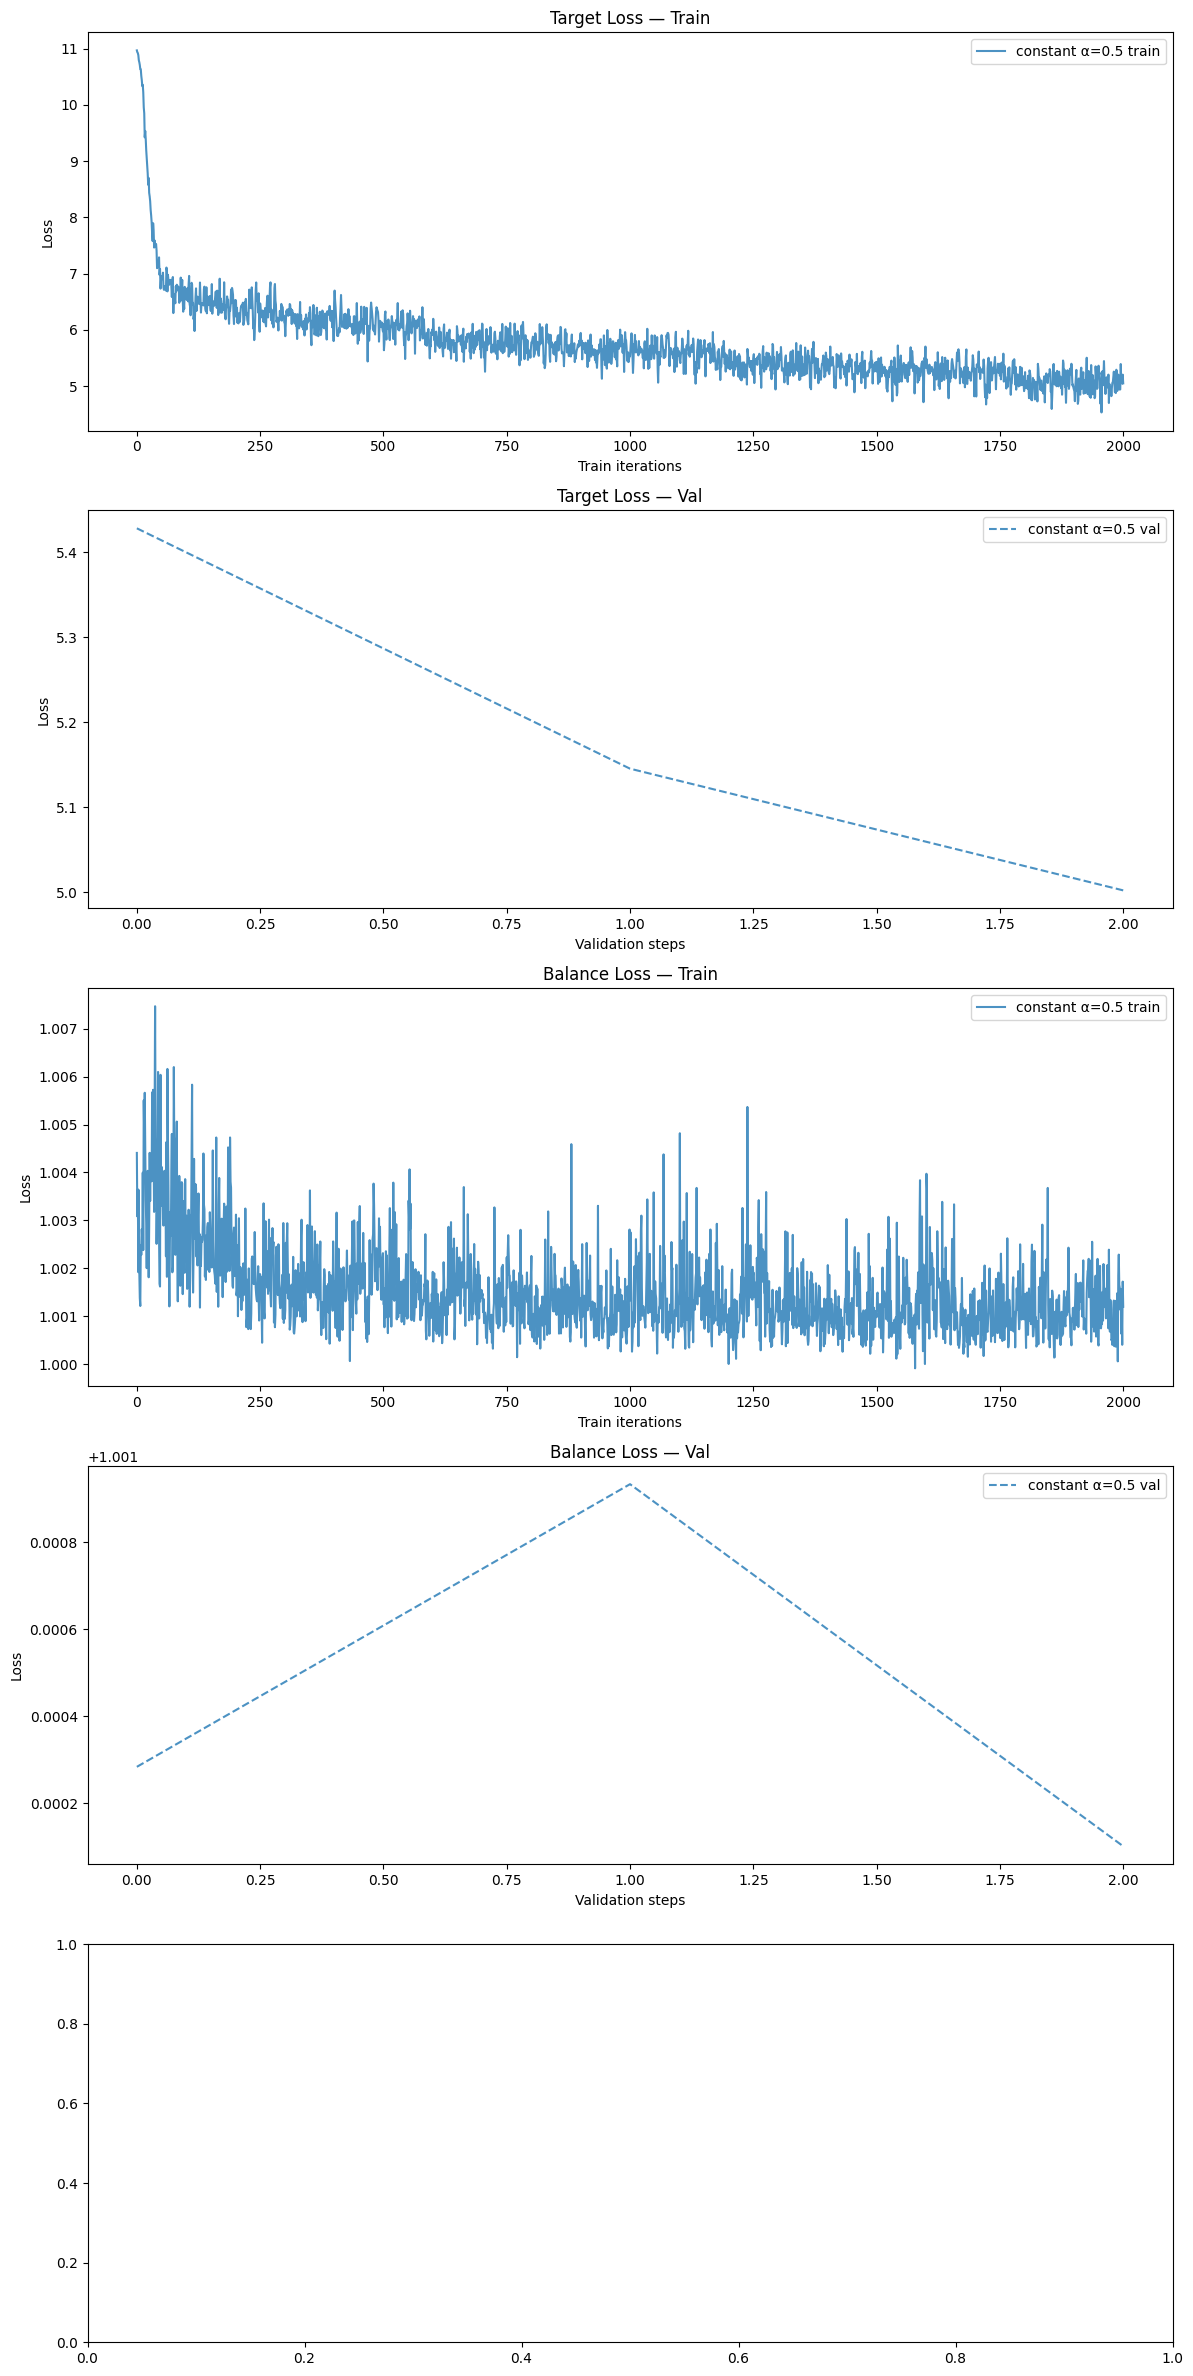

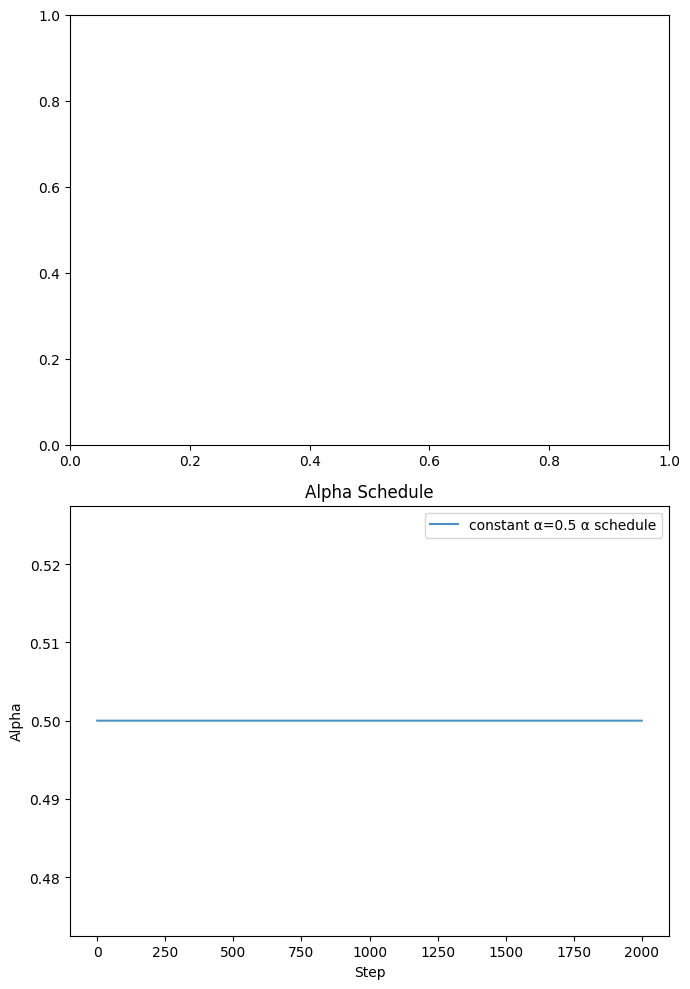

In [34]:
visualize_experiments(['constant_alpha0.50_gpu4'], suffix=None, distr=True)

In [120]:
from datasets import load_dataset
from transformers import GPT2Tokenizer
import tqdm  # для прогресс-бара

# Загрузка токенизатора GPT-2
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Загрузка датасета (можно заменить на wikitext-2-raw-v1 или другой)
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

# Подсчет общего числа токенов
total_tokens = 0

for text in tqdm.tqdm(dataset["text"]):
    if text.strip():  # Пропускаем пустые строки
        tokens = tokenizer(text, return_tensors="pt", truncation=False)["input_ids"]
        total_tokens += tokens.shape[1]  # Добавляем число токенов в тексте

print(f"Общее число токенов: {total_tokens:,}")

/home/vasilievpavel4/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 36718/36718 [00:17<00:00, 2146.04it/s]

Общее число токенов: 2,391,884


In [46]:
!pip install transformers

  Using cached transformers-4.55.0-py3-none-any.whl.metadata (39 kB)
  Using cached regex-2025.7.34-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.21.4-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached safetensors-0.6.1-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
Using cached transformers-4.55.0-py3-none-any.whl (11.3 MB)
Using cached tokenizers-0.21.4-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.1 MB)
Using cached regex-2025.7.34-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
Using cached safetensors-0.6.1-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (485 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [transformers] [transformers]
